# `trim_saddle_points_legacy`
Removes peaks that fall on a saddle or ridge in the distance transform rather than on a true local maximum. This is the version that shipped with PoreSpy < 2; it is more aggressive in trimming than the current `trim_saddle_points` and is kept for legacy reasons.

In [1]:
import matplotlib.pyplot as plt

import porespy as ps
from porespy.tools import get_edt

ps.visualization.set_mpl_style()

The arguments and their defaults are:

In [2]:
import inspect

inspect.signature(ps.filters.trim_saddle_points_legacy)

<Signature (peaks, dt, maxiter=10)>

## `peaks` and `dt`
`peaks` is a boolean image with `True` at candidate peak locations (typically the output of `find_peaks` plus `reduce_peaks`); `dt` is the distance transform of the void phase the peaks were found in.

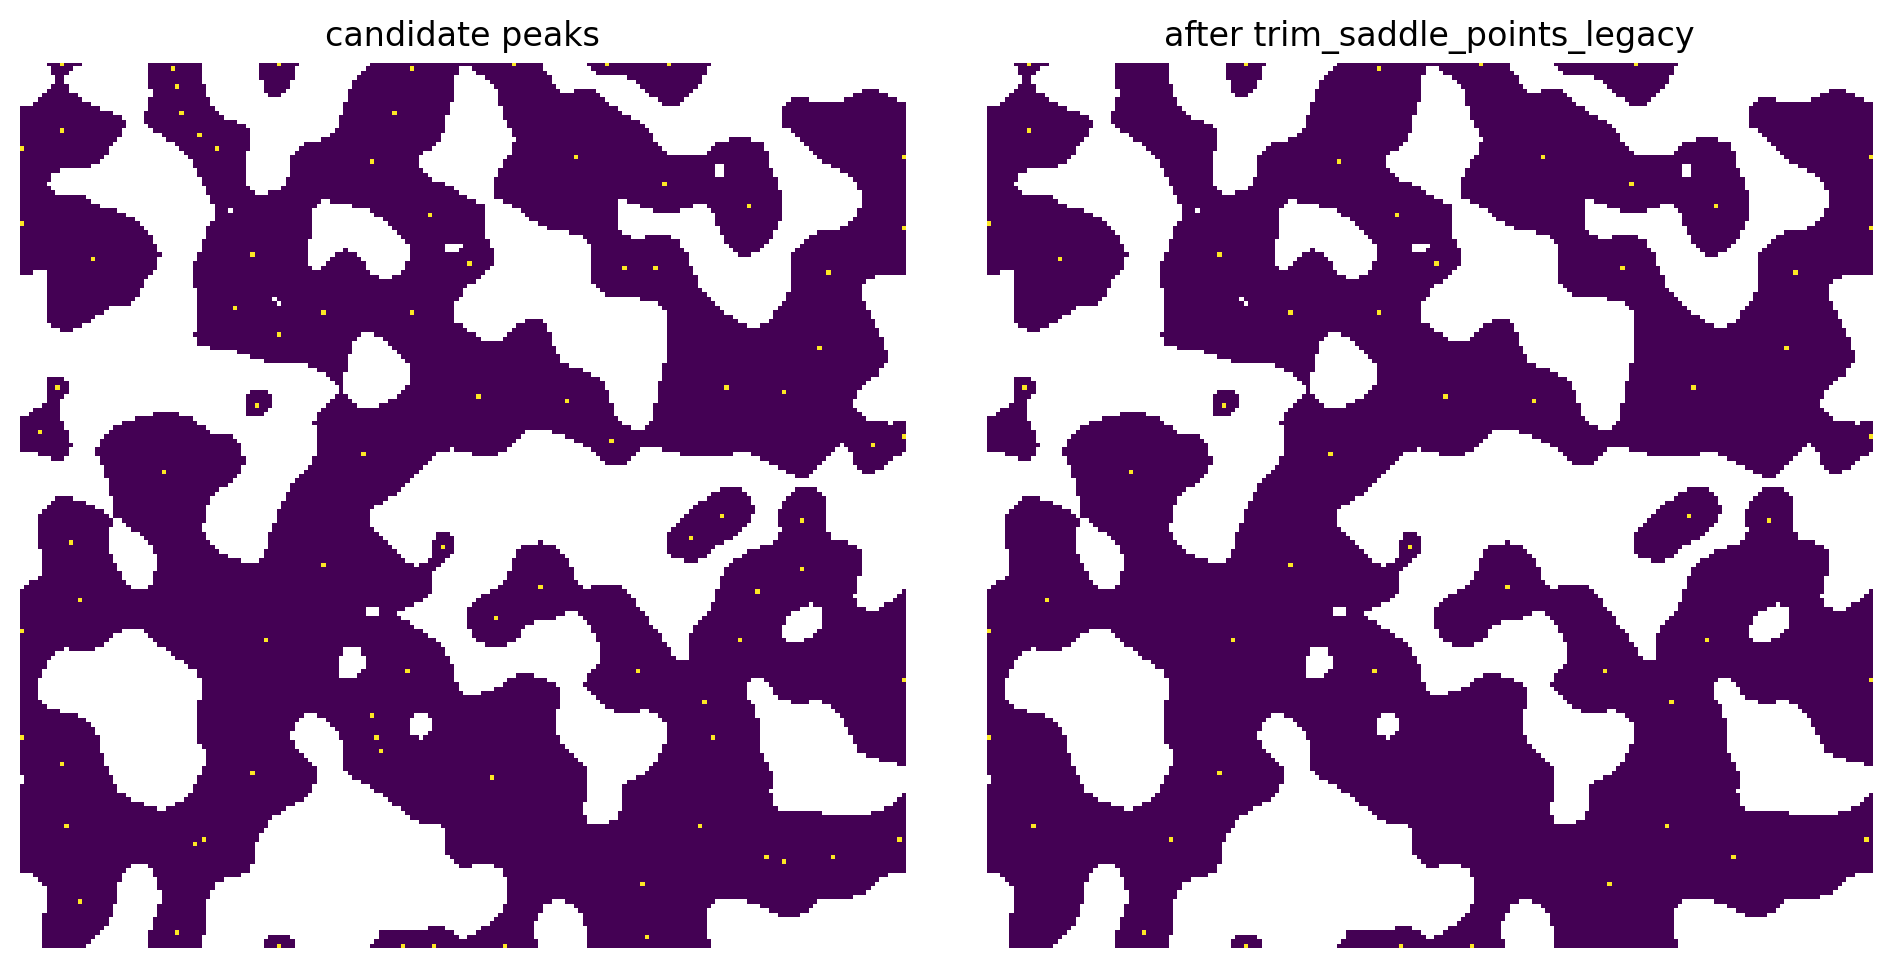

In [3]:
im = ps.generators.blobs(shape=[200, 200], porosity=0.6, seed=0)
dt = get_edt()(im)
peaks = ps.filters.find_peaks(dt=dt)
peaks = ps.filters.reduce_peaks(peaks=peaks)

trimmed = ps.filters.trim_saddle_points_legacy(peaks=peaks, dt=dt)

fig, ax = plt.subplots(1, 2, figsize=[10, 5])
ax[0].imshow(peaks / im, origin='lower', interpolation='none')
ax[0].set_title('candidate peaks')
ax[0].axis(False)
ax[1].imshow(trimmed / im, origin='lower', interpolation='none')
ax[1].set_title('after trim_saddle_points_legacy')
ax[1].axis(False);

## `maxiter`
Maximum number of iterations the dilation-and-compare loop is allowed to run per peak before giving up. The default is 10. If you suspect peaks are being spuriously dropped, increase this.

In [4]:
for n in [3, 10, 30]:
    trimmed = ps.filters.trim_saddle_points_legacy(
        peaks=peaks, dt=dt, maxiter=n)
    print(f'maxiter = {n:>2}  ->  peaks remaining: {int(trimmed.sum())}')

maxiter =  3  ->  peaks remaining: 61
maxiter = 10  ->  peaks remaining: 55
maxiter = 30  ->  peaks remaining: 55


> **Note**
> For new code, use `trim_saddle_points`. This legacy function is kept only to reproduce results from PoreSpy < 2.